# 固定済み before / after ペアの Lab 解析

この notebook は探索をしません。`makeup.mp4` なら `outputs/makeup/selected_pair.json` を使います。
探索側と同じ `VIDEO` ファイル名を指定するだけです。


In [13]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
marker = Path('analysis/analyze_cheek_lab.py')
if (cwd / marker).is_file():
    REPO_ROOT = cwd
elif cwd.name == 'notebooks' and (cwd.parent / marker).is_file():
    REPO_ROOT = cwd.parent
    os.chdir(REPO_ROOT)
else:
    raise RuntimeError(f'ikiikimake のリポジトリ直下または notebooks/ から実行してください: current={cwd}')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('repo root:', Path.cwd())

repo root: C:\Users\mail\work\ikiikimake


## 設定


In [14]:
VIDEO = Path('makeup0923.mp4')
OUTPUT = Path('outputs') / VIDEO.stem
SELECTED = OUTPUT / 'selected_pair.json'
LAB_OUTPUT = OUTPUT / 'lab_selected_pair'

if not SELECTED.is_file():
    raise FileNotFoundError(
        f'承認済みペアがありません: {SELECTED}. '
        '先に video_before_after_pair.ipynb で候補を固定してください。'
    )

print('selected pair:', SELECTED)
print('lab output   :', LAB_OUTPUT)

selected pair: outputs\makeup0923\selected_pair.json
lab output   : outputs\makeup0923\lab_selected_pair


## 固定済みペアを検証して解析

元画像と ROI 成果物の SHA-256 を再検証します。既存の Lab 出力が同じ入力から作られたものなら再利用し、`summary.html` がなければ追加します。入力が違えば停止します。


In [15]:
import hashlib
import json

from analysis.analyze_cheek_lab import analyze_pair, write_summary_html

if not SELECTED.is_file():
    raise FileNotFoundError(f'selected_pair.json がありません: {SELECTED}')

selected = json.loads(SELECTED.read_text(encoding='utf-8'))
if Path(selected.get('video_path', '')).resolve() != VIDEO.resolve():
    raise RuntimeError('selected_pair.json の動画と VIDEO が一致しません。')

def sha256_file(path: Path) -> str:
    if not path.is_file():
        raise FileNotFoundError(path)
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def checked_file(path: Path, expected_sha256: str, label: str) -> Path:
    actual = sha256_file(path)
    if actual != expected_sha256:
        raise RuntimeError(
            f'{label} の SHA-256 が一致しません。'
            f' expected={expected_sha256} actual={actual} path={path}'
        )
    return path

resolved = {}
for phase in ('before', 'after'):
    item = selected.get(phase)
    if not isinstance(item, dict):
        raise ValueError(f'selected_pair.json に {phase} がありません。')
    image = checked_file(Path(item['image_path']), item['image_sha256'], f'{phase} image')
    roi_dir = Path(item['roi_dir'])
    masks = checked_file(roi_dir / 'roi_masks.npz', item['roi_masks_sha256'], f'{phase} roi_masks')
    checked_file(roi_dir / 'roi_points.json', item['roi_points_sha256'], f'{phase} roi_points')
    checked_file(roi_dir / 'roi_overlay.png', item['roi_overlay_sha256'], f'{phase} roi_overlay')
    resolved[phase] = {'image': image, 'masks': masks}

summary_path = LAB_OUTPUT / 'analysis_summary.json'
if LAB_OUTPUT.exists():
    if not summary_path.is_file():
        raise FileExistsError(
            f'Lab出力フォルダはありますが analysis_summary.json がありません: {LAB_OUTPUT}'
        )
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    expected_inputs = {
        'before': str(resolved['before']['image'].resolve()),
        'after': str(resolved['after']['image'].resolve()),
        'before_masks': str(resolved['before']['masks'].resolve()),
        'after_masks': str(resolved['after']['masks'].resolve()),
    }
    if summary.get('inputs') != expected_inputs:
        raise RuntimeError(
            '既存Lab解析の入力が現在の selected_pair.json と一致しません。'
            f' expected={expected_inputs} saved={summary.get("inputs")}'
        )
    summary_html = write_summary_html(LAB_OUTPUT, summary)
    print('既存Lab解析を検証して再利用しました:', LAB_OUTPUT)
    print('summary:', summary_html)
else:
    summary = analyze_pair(
        resolved['before']['image'],
        resolved['after']['image'],
        resolved['before']['masks'],
        resolved['after']['masks'],
        LAB_OUTPUT,
    )
    print('Lab analysis complete:', LAB_OUTPUT)
    print('summary:', LAB_OUTPUT / 'summary.html')

Lab analysis complete: outputs\makeup0923\lab_selected_pair
summary: outputs\makeup0923\lab_selected_pair\summary.html


## 結果

`delta` は after − before、`delta_minus_forehead` は `(頬 after − before) − (額 after − before)` です。額差し引きは未検証の control 比較で、照明補正やメイク効果の確定値ではありません。


In [16]:
from IPython.display import HTML, display

summary_path = LAB_OUTPUT / 'analysis_summary.json'
if not summary_path.is_file():
    raise FileNotFoundError(summary_path)
summary = json.loads(summary_path.read_text(encoding='utf-8'))

rows = [row for row in summary['deltas'] if row['metric'] in ('a_median', 'a_mean')]
if not rows:
    raise RuntimeError('a* の差分結果がありません。')

headers = ('side', 'metric', 'before', 'after', 'delta', 'forehead_delta', 'delta_minus_forehead')
head = ''.join(f'<th>{name}</th>' for name in headers)
body = []
for row in rows:
    cells = []
    for name in headers:
        value = row[name]
        cells.append(f'<td>{value:.3f}</td>' if isinstance(value, float) else f'<td>{value}</td>')
    body.append('<tr>' + ''.join(cells) + '</tr>')

display(HTML('<table><thead><tr>' + head + '</tr></thead><tbody>' + ''.join(body) + '</tbody></table>'))

side,metric,before,after,delta,forehead_delta,delta_minus_forehead
left_cheek,a_mean,12.188,16.112,3.925,0.183,3.742
left_cheek,a_median,12.000,16.000,4.000,1.000,3.000
right_cheek,a_mean,10.915,11.602,0.686,0.183,0.504
right_cheek,a_median,11.000,12.000,1.000,1.000,0.000


## 生成ファイル


In [17]:
required = [
    'summary.html',
    'analysis_summary.json',
    'lab_stats.csv',
    'lab_deltas.csv',
    'roi_samples.png',
    'left_cheek_lab_hist.png',
    'right_cheek_lab_hist.png',
    'forehead_lab_hist.png',
]
for name in required:
    path = LAB_OUTPUT / name
    if not path.is_file():
        raise FileNotFoundError(path)
    print(path)

print('\nまず見るファイル:', (LAB_OUTPUT / 'summary.html').resolve())

outputs\makeup0923\lab_selected_pair\summary.html
outputs\makeup0923\lab_selected_pair\analysis_summary.json
outputs\makeup0923\lab_selected_pair\lab_stats.csv
outputs\makeup0923\lab_selected_pair\lab_deltas.csv
outputs\makeup0923\lab_selected_pair\roi_samples.png
outputs\makeup0923\lab_selected_pair\left_cheek_lab_hist.png
outputs\makeup0923\lab_selected_pair\right_cheek_lab_hist.png
outputs\makeup0923\lab_selected_pair\forehead_lab_hist.png

まず見るファイル: C:\Users\mail\work\ikiikimake\outputs\makeup0923\lab_selected_pair\summary.html


## 部位別の見た目を評価する

目元・眉・唇のコントラスト、頬の赤み・色ばらつき・明部率を、選択済みの同じ2枚で比較します。
値の増減は「よくなった／悪くなった」という判定ではありません。総合印象・いきいき感・自然さは、目視評価と別に記録します。

- 元PNGの画素を測定します。拡大表示で画素数を水増ししません。
- 額を照明補正用の基準とは扱いません。顔向き、視線、表情、照明、ピントの影響は残ります。
- 新しく作る眉・目元・唇のROIは、下の重ね合わせで位置や手・道具・髪の混入を確認してください。
- 画素が不足した指標は **判定不可** になります。シワの細かさや深さは今回の処理では評価しません。


In [18]:
import importlib
import analysis.appearance_features as appearance_features
import analysis.analyze_appearance as appearance_analysis

# A rerun in the same kernel must use the current measurement implementation.
importlib.reload(appearance_features)
importlib.reload(appearance_analysis)
summary_html = appearance_analysis.summary_html

APPEARANCE_OUTPUT = OUTPUT / 'appearance_selected_pair'
appearance = appearance_analysis.analyze_selected_appearance(SELECTED, APPEARANCE_OUTPUT)
APPEARANCE_RUN = Path(appearance['output_dir'])

print('部位別の比較結果:', APPEARANCE_RUN)
print('比較レポート    :', APPEARANCE_RUN / 'report.html')


部位別の比較結果: C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a
比較レポート    : C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\report.html


### 測定範囲を確認

白い線の領域は、眉・上まぶた・唇と比較する周囲の肌です。
測定範囲がずれている場合や、手・筆・文字などが入っている場合は、その部位の結果を採用しないでください。


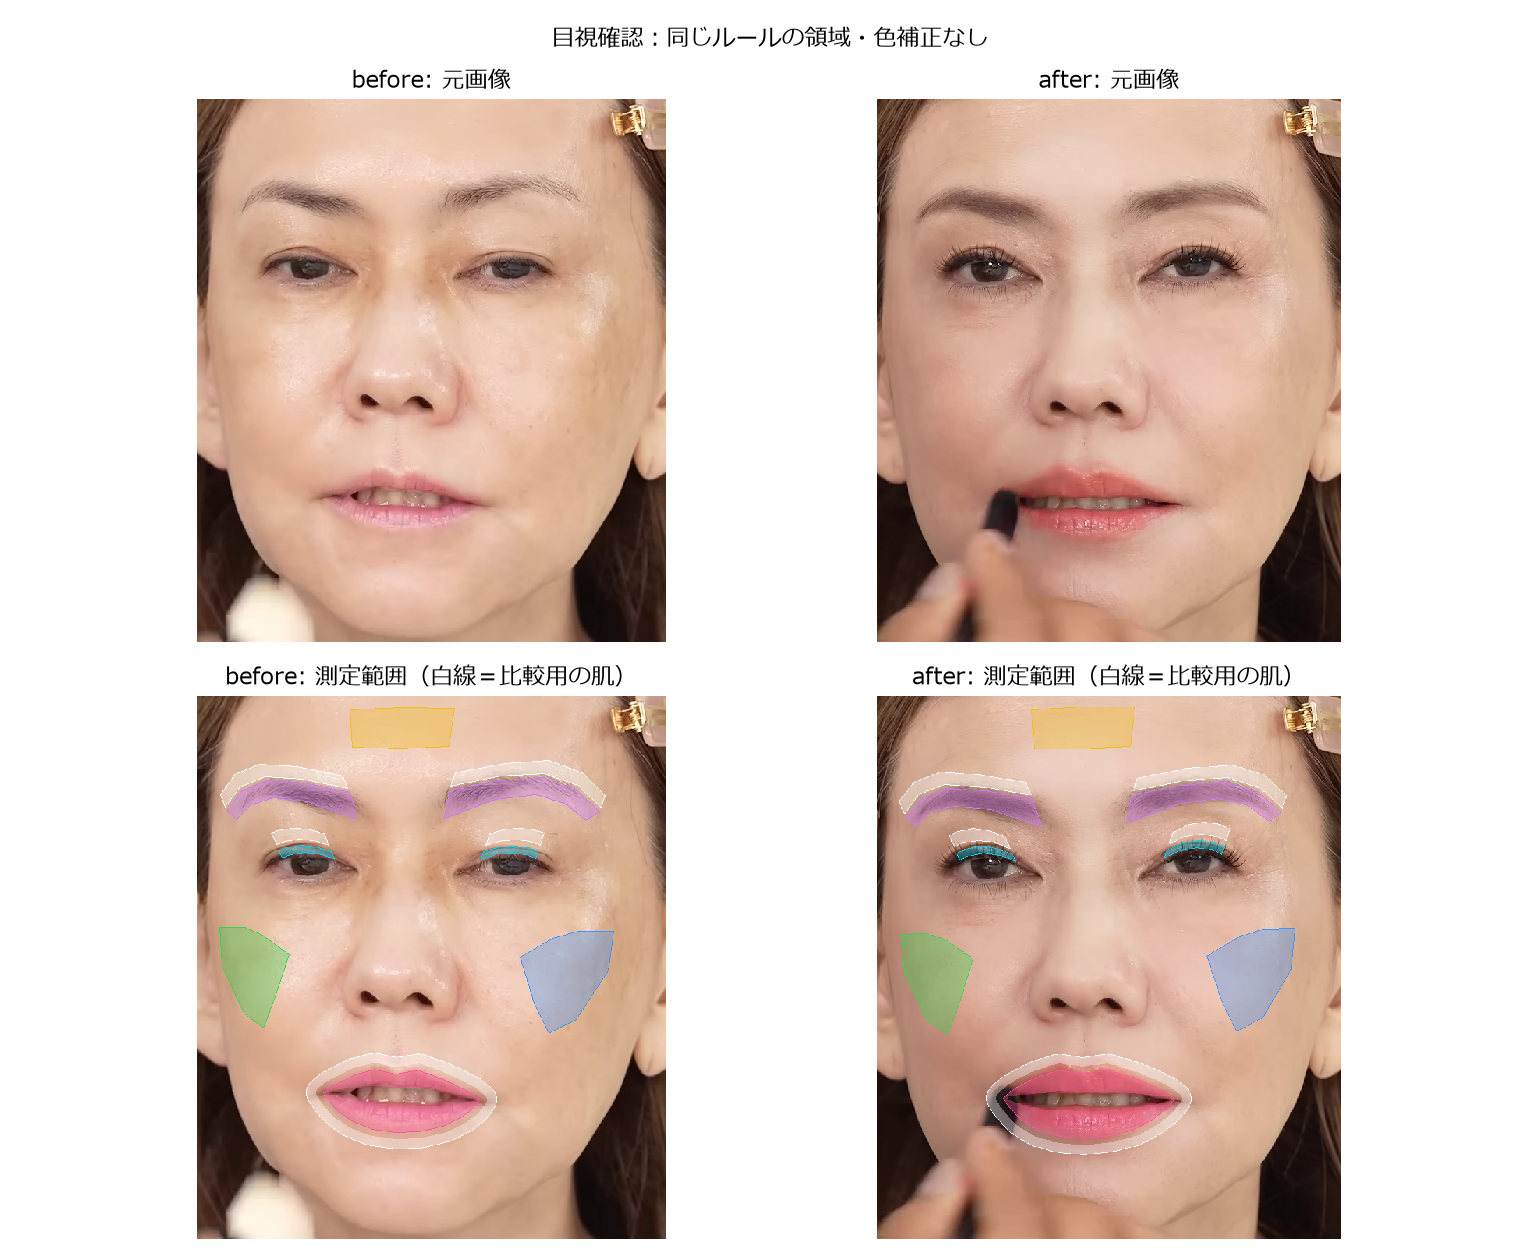

指標,単位,before,after,差,状態
画面左眉の相対明度コントラスト,L*,28.70,32.87,+4.17,測定値あり・要目視
画面左上まぶた外側帯の相対明度コントラスト,L*,26.84,45.83,+18.99,測定値あり・要目視
画面右眉の相対明度コントラスト,L*,20.84,30.35,+9.51,測定値あり・要目視
画面右上まぶた外側帯の相対明度コントラスト,L*,24.98,38.76,+13.78,測定値あり・要目視
唇と周囲皮膚のa*差,a*,13.38,19.44,+6.06,測定値あり・要目視
唇と周囲皮膚のLab色差,ΔE*ab（CIE76）,16.40,23.33,+6.94,測定値あり・要目視
画面左頬のL*中央値,L*,76.10,66.81,-9.30,測定値あり・要目視
画面左頬のa*中央値,a*,12.38,15.84,+3.47,測定値あり・要目視
画面左頬のb*中央値,b*,20.42,17.72,-2.70,測定値あり・要目視
画面左頬の色ばらつき,Lab a*b*距離,1.36,0.89,-0.47,測定値あり・要目視


In [19]:
from IPython.display import Image, HTML, display

display(Image(filename=str(APPEARANCE_RUN / 'appearance_rois.png'), width=1000))
display(HTML(summary_html(appearance)))


### before / after の変化

青色はafterの値を表し、改善を意味する色ではありません。指標ごとに単位と意味が違うため、単純に足し合わせて総合点にはしません。
唇の色差は「唇と周囲の肌との色の違い」、明部率は「頬の中で相対的に明るい部分の割合」です。


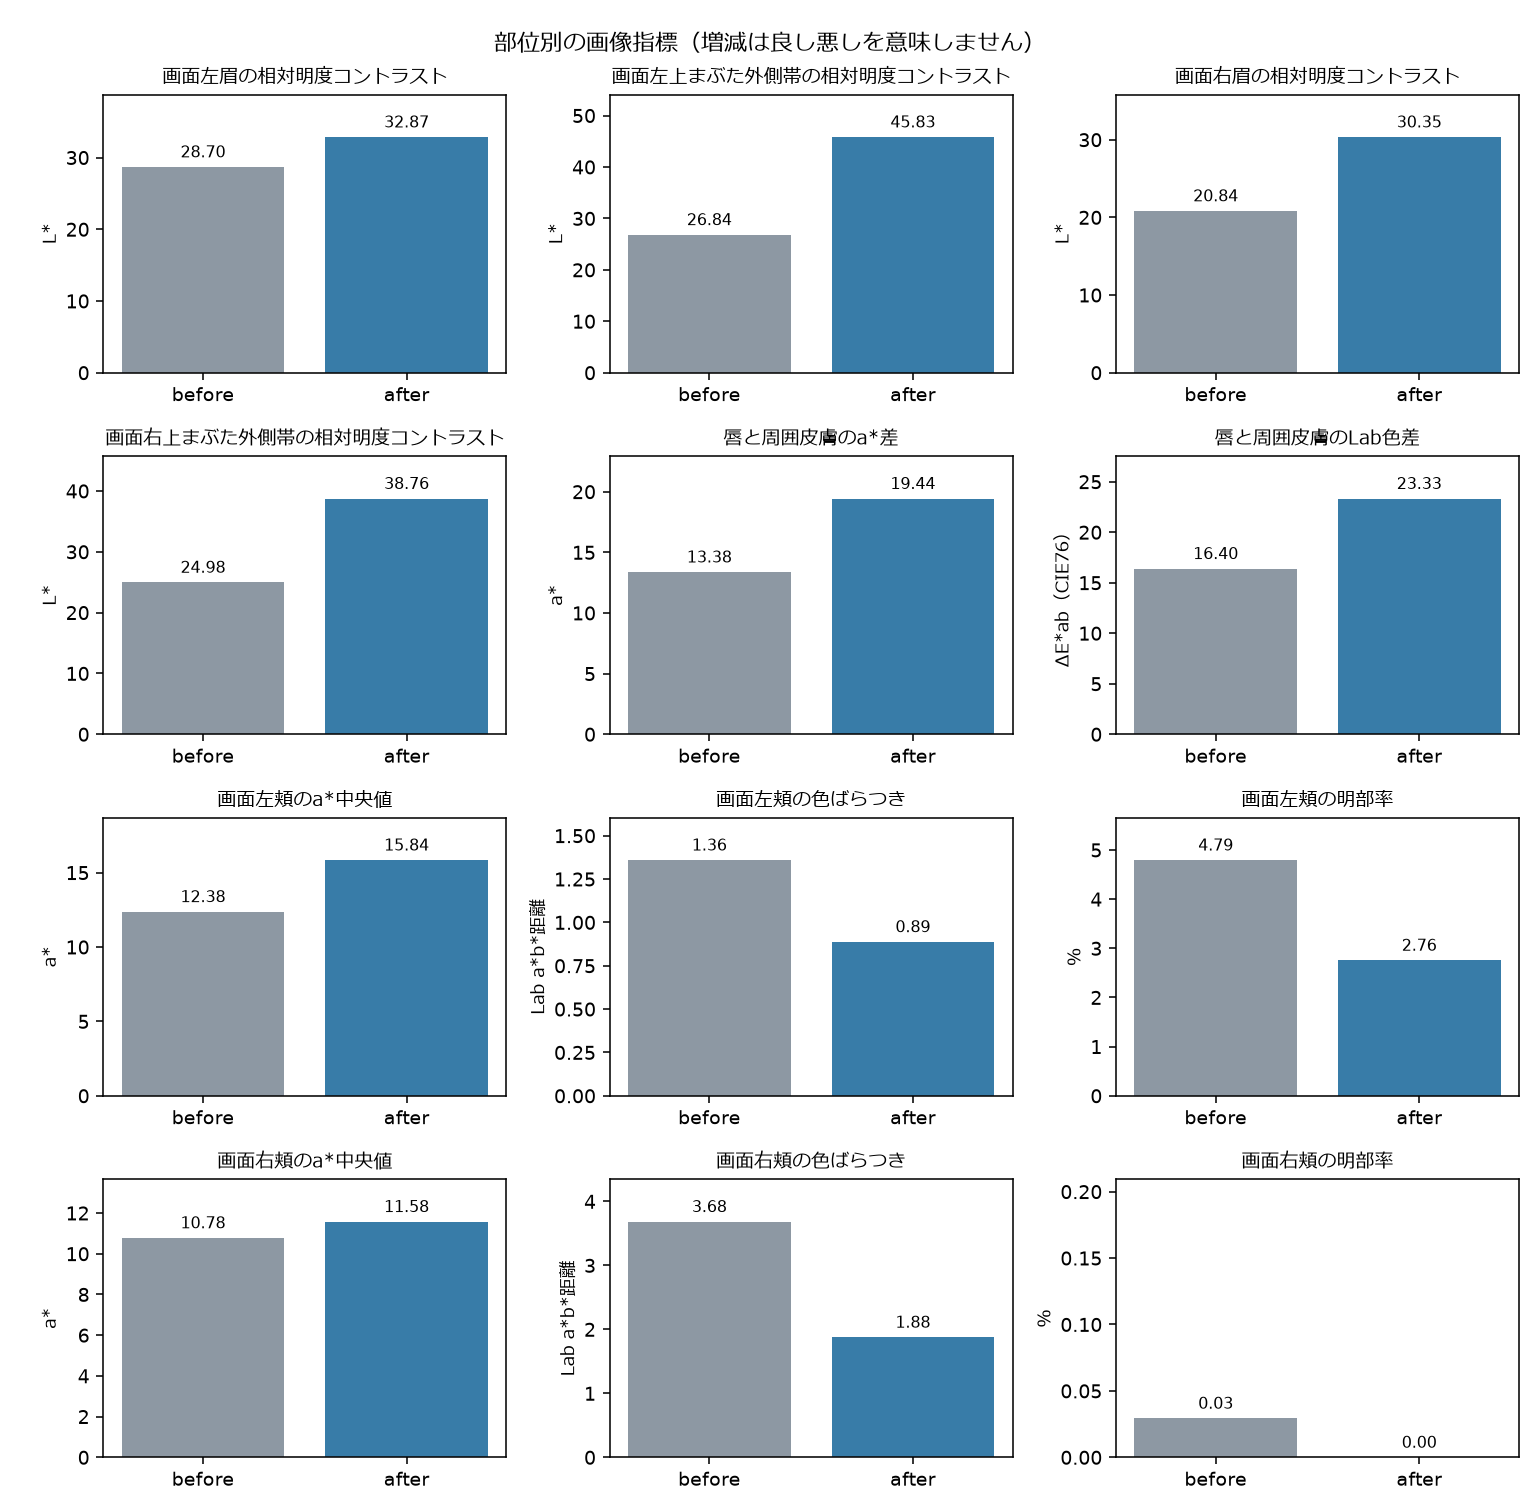

C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\report.html
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\feature_summary.json
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\feature_deltas.csv
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\appearance_rois.png
C:\Users\mail\work\ikiikimake\outputs\makeup0923\appearance_selected_pair\61a4495b7645be3a\region_samples.png


In [20]:
display(Image(filename=str(APPEARANCE_RUN / 'feature_changes.png'), width=1100))

for name in ('report.html', 'feature_summary.json', 'feature_deltas.csv',
             'appearance_rois.png', 'region_samples.png'):
    print((APPEARANCE_RUN / name).resolve())


### 任意：人が見た印象を記録する

下の `None` を `"after"`（afterのほうがよい）、`"same"`（同程度）、`"before"`（beforeのほうがよい）、
`"cannot_judge"`（比較条件などにより判断できない）のいずれかに変更できます。
未入力のままなら保存しません。これは自動計算結果から生成する評価ではなく、見た人の判断の記録です。
同じ比較の記録を更新する場合は、入力した内容で `visual_review.json` を更新します。


In [21]:
VISUAL_REVIEW = {
    'overall': None,       # 顔全体として好ましいか
    'lively': None,        # いきいきして見えるか
    'natural': None,       # 自然な仕上がりに見えるか
    'note': '',            # そう判断した理由、比較条件の問題など
}

allowed = {None, 'after', 'same', 'before', 'cannot_judge'}
if any(VISUAL_REVIEW[key] not in allowed for key in ('overall', 'lively', 'natural')):
    raise ValueError('目視評価は after / same / before / cannot_judge / None から選んでください。')
if not isinstance(VISUAL_REVIEW['note'], str):
    raise TypeError('noteは文字列にしてください。')
if any(VISUAL_REVIEW[key] is not None for key in ('overall', 'lively', 'natural')) or VISUAL_REVIEW['note'].strip():
    visual_record = {
        'schema_version': 1,
        'appearance_fingerprint': appearance['fingerprint'],
        'inputs': appearance['input_specification']['inputs'],
        'review_source': 'human_entered_in_notebook',
        'rating': VISUAL_REVIEW,
    }
    review_path = APPEARANCE_RUN / 'visual_review.json'
    review_path.write_text(json.dumps(visual_record, ensure_ascii=False, indent=2), encoding='utf-8')
    print('目視評価を保存:', review_path)
else:
    print('目視評価は未入力です。既存の目視記録は変更していません。')


目視評価は未入力です。既存の目視記録は変更していません。
